In [5]:
import bagpipes as pipes
import numpy as np
import matplotlib.pyplot as plt

def generate_bc03_reference(age_gyr=0.1, metallicity=0.2, z=0.0):
    """
    使用 Bagpipes 生成一个无尘埃的恒星连续谱 (模拟 BC03/BPASS 结果)

    参数:
    age_gyr: 星系年龄 (Gyr)。对于 z=3-7 的 Reference，通常很年轻 (e.g., 0.05 - 0.2 Gyr)
    metallicity: 金属丰度 (Z/Z_solar)。高红移通常较低 (e.g., 0.1 - 0.4)
    z: 红移。为了和你的 rest-frame 数据对比，这里设为 0 (静止系)
    """

    # 1. 定义模型参数字典
    model_components = {}

    # --- 恒星形成历史 (SFH) ---
    # 使用简单的 Constant (CSF) 或 Delayed-Tau 模型
    model_components["constant"] = {
        "age_max": age_gyr,      # 恒星形成开始的时间
        "age_min": 0.,           # 最年轻恒星的年龄
        "massformed": 9.0,       # log10 总恒星质量 (归一化后这个值不重要)
        "metallicity": metallicity # 金属丰度
    }

    # --- 尘埃 (关键步骤！) ---
    # 我们需要 Reference，所以必须把尘埃设为 0
    model_components["dust"] = {
        "type": "Calzetti",      # 尘埃定律类型
        "Av": 0.0,               # <--- 设为 0，即无尘埃衰减
        "eta": 1.0               # 仅仅是占位符
    }

    # --- 气体发射线 (可选) ---
    # 如果你的观测 Reference 已经 mask 掉了发射线，
    # 建议这里把 nebular 关掉，或者设为很低，只看 Continuum
    # model_components["nebular"] = {
    #     "logU": -2.0             # 电离参数
    # }

    # --- 红移 ---
    model_components["redshift"] = z

    # 2. 生成光谱
    # Bagpipes 会自动调用底层的 SPS 模型 (通常是 BC03 2016 更新版或 BPASS)
    model = pipes.model_galaxy(model_components, spec_wavs=np.arange(500, 8000, 5)) # 不传滤光片，只生成光谱

    # 提取波长和光通量
    # model.spectrum 格式通常是 [wavelength (Angstrom), flux]
    wavelengths = model.spectrum[:, 0]
    fluxes = model.spectrum[:, 1]

    return wavelengths, fluxes

# --- 主程序：与你的观测数据对比 ---

# 1. 生成理论模型 (假设 Reference 是 100 Myr, 0.2 Z_sun 的星系)
model_wave, model_flux = generate_bc03_reference(age_gyr=0.1, metallicity=0.2)


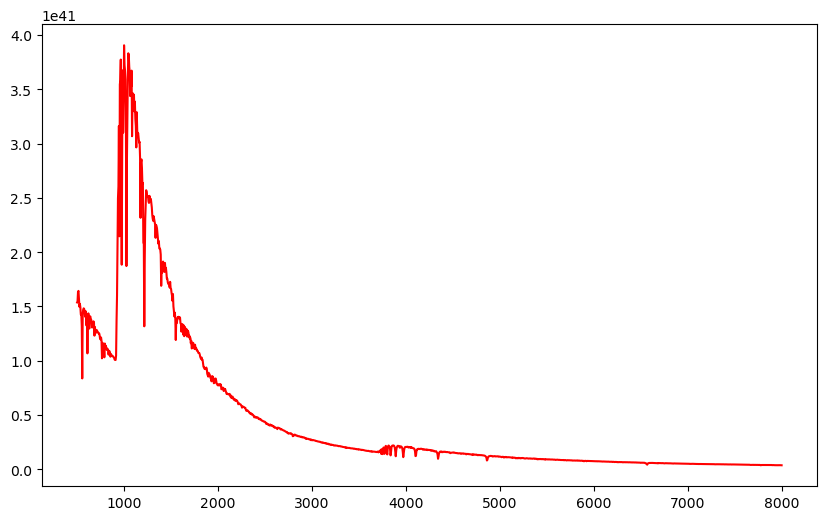

In [7]:
plt.figure(figsize=(10, 6))
plt.plot(np.arange(500, 8000, 5), model_flux, 'r', label='BC03/Bagpipes Model (No Dust, 100 Myr)', lw=1.5)
